In [317]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [318]:
def data_simulation(sample_size, scale, period, variance):

    x = np.random.uniform(-scale, scale, sample_size)
    x.sort()
    noise = np.random.normal(0, variance, sample_size)
    y = x * np.cos(x / period) + noise
    
    return x, y

In [319]:
def scatter_plot(x_train, x_test, y_train, y_test):
    plt.figure(figsize=(15, 5))
    plt.plot(x_train, y_train, '.', color = 'black', markersize = 3, label = 'train')
    plt.plot(x_test, y_test, '.', color = 'red', markersize = 8, label = 'test')

    plt.xlabel('X')
    plt.ylabel('Y')
    leg = plt.legend(loc = 'lower center', fontsize = 'large')
    leg.get_frame().set_alpha(0)
    return plt

In [320]:
def MSE(a, b):
    return ((a - b)**2).mean()

In [321]:
def plot_polynomial_curves(x_train, x_test, y_train, y_test, degree, scale):

    plt = scatter_plot(x_train, x_test, y_train, y_test)

    loss_train_stack, loss_test_stack = [], []
    color = cm.rainbow(np.linspace(0, 1, len(degree)))

    for k, c in zip(range(len(degree)), color):
        coef = np.polyfit(x_train, y_train, degree[k])

        y_hat_train = np.polyval(coef, x_train)
        y_hat_test = np.polyval(coef, x_test)

        loss_train_stack.append(MSE(y_hat_train, y_train))
        loss_test_stack.append(MSE(y_hat_test, y_test))

        print('Polynomial degree: ', degree[k], ' | MSE train:', np.round(loss_train_stack[-1], 4), ' | MSE test:', np.round(loss_test_stack[-1], 4))

        x_draw = np.linspace(-scale, scale, num = 200)
        y_draw = np.polyval(coef, x_draw)

        plt.plot(x_draw, y_draw, color = c, label = degree[k])
        plt.ylim(min(min(y_train), min(y_test)), max(max(y_train), max(y_test)))


    leg = plt.gca().legend(loc='center left', bbox_to_anchor=(1, .65), title="Polynomial degree of  \n  the fitted curve \n")
    leg.get_frame().set_alpha(0)

In [322]:
def train_poly_and_see(sample_size, scale, period, variance, degree):

    H_train = np.zeros((len(sample_size), len(degree)))
    H_test = np.zeros((len(sample_size), len(degree)))

    optimal_train, optimal_test, optimal_degree = [], [], []

    i = 0
    for n in sample_size:
        x_train, y_train = data_simulation(n, scale, period, variance)
        x_test, y_test = data_simulation(1000, scale, period, variance)

        j = 0
        for k in degree:
            coef = np.polyfit(x_train, y_train, k)

            y_hat_train = np.polyval(coef, x_train)
            y_hat_test = np.polyval(coef, x_test)

            H_train[i, j] = MSE(y_hat_train, y_train)
            H_test[i, j] = MSE(y_test, y_hat_test)
            j += 1

        optimal_degree.append(np.argmin(H_test[i, :]))
        optimal_train.append(H_train[i, np.argmin(H_train[i, :])])
        optimal_test.append(H_test[i, np.argmin(H_test[i, :])])

        i += 1
    
    return H_train, H_test, optimal_train, optimal_test, optimal_degree

In [323]:
sample_size = [10, 10**2, 10**3, 10**4, 10**5, 10**6]
variance = 20
scale = 100
period = 6
degree = [0, 1, 3, 5, 10, 20, 50]

np.random.seed(2)

H_train, H_test, optimal_train, optimal_test, optimal_degree = train_poly_and_see(sample_size, scale, period, variance, degree)

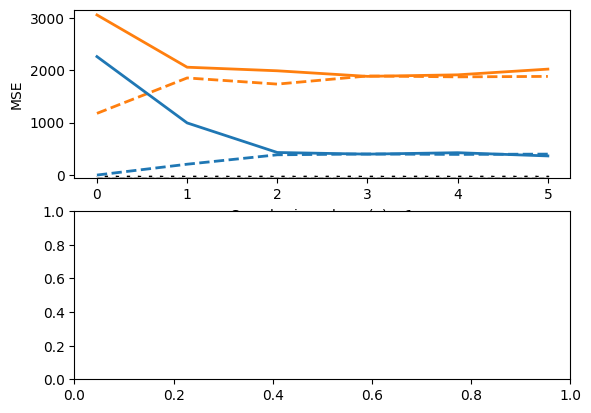

In [334]:
cmap = plt.get_cmap("tab10")   # Because I prefer this color map

H = np.concatenate((optimal_train, optimal_test, H_train[:,2], H_test[:,2]), axis=0)
mini, maxi = min(H), max(H)
linewidth = 2
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)#, layout='constrained')#, figsize=(30,5))
#ax2 = ax1.twinx()
#ax2 = ax[1]

# Home made tricks for great legend
ax1.plot([-20] * len(optimal_train),  label='Test', color='k', linewidth=1)
ax1.plot([-20] * len(optimal_train), label='Training', linestyle='dashed', color='k', linewidth=1)
ax1.plot([-20] * len(optimal_train), label='     ', linestyle='dashed', color='white')

ax1.plot(H_train[:,2], color=cmap(1), linestyle='dashed', linewidth=linewidth)   # Since we are interested in the cubic curve
ax1.plot(H_test[:,2], color=cmap(1), label='Cubic',linewidth=linewidth)
ax1.set_xlabel('Sample size:  $\ \log_{10}(n) - 1$')
ax1.set_ylabel('MSE')
ax1.set_ylim(mini-50, maxi+100)
ax1.plot(optimal_train, color=cmap(0), linestyle='dashed', linewidth=linewidth)   # Since we are 'also' interested in the optimal curve
ax1.plot(optimal_test, color=cmap(0), label='Optimal Capacity', linewidth=linewidth)


# plt.xticks([0, 1, 2, 3, 4, 5])
# leg1 = ax1.legend(loc='center left', bbox_to_anchor=(1.1, .8))   # Legend location is somehow important to me
# leg1.get_frame().set_alpha(0)   # Legend without frame > legend with frame imo

# #plt.show()

# ax2.plot(optimal_degree, color=cmap(2), label='Optimial degree', linewidth=linewidth)   # Optimal degree with respect to the sample size
# ax2.set_ylabel('Degree of the polynomial', fontsize=12, color = 'green')
# ax2.set_xlabel('Sample size:  $\ \log_{10}(n) - 1$')
# leg2 = ax2.legend(loc='center left', bbox_to_anchor=(1.1, .8))   # Legend location is somehow important to me
# leg2.get_frame().set_alpha(0)   # Legend without frame > legend with frame imo

# plt.show()

In [325]:
H

array([2.40932306e-15, 2.06957479e+02, 3.86757285e+02, 4.02019501e+02,
       3.94130846e+02, 3.99847200e+02, 2.26126346e+03, 9.95304907e+02,
       4.30709012e+02, 3.99327925e+02, 4.26861880e+02, 3.65211320e+02,
       1.17745512e+03, 1.85376476e+03, 1.73632746e+03, 1.89148987e+03,
       1.87443975e+03, 1.88317129e+03, 3.05699785e+03, 2.05875009e+03,
       1.99045933e+03, 1.88403445e+03, 1.91331806e+03, 2.02220235e+03])